<a href="https://colab.research.google.com/github/yuukienomoto/report_ynu/blob/main/mahjong0608.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ステップ1：戦略スタッツを回収する新コードを実行する
強者と弱者のデータを、戦略指標に特化させて集め直す。


In [14]:
import requests
import pandas as pd
import time
import random

# 強者IDと弱者ID
strong_ids = [
    69951433, 22972779, 22894632, 22973070, 23729152,
    71422442, 16649391, 15382278, 23033659, 19962975,
    104564308, 22822483, 10522750, 22385265, 107657464,
    74242510, 11080050, 103300048, 105175217, 105249170
]

weak_ids = [
    11938083, 10363720, 13006690, 102366130, 105161885,
    11289858, 14298128, 18595396, 104740148, 103572512,
    69368978, 67198142, 23006975, 103761154, 107729898,
    102228865, 120489479, 103037043, 22973481
]

URL_TEMPLATE = "https://5-data.amae-koromo.com/api/v2/pl4/player_extended_stats/{pid}/1262304000000/1780896539999?mode=16.12.9.15.11.8"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

def collect_true_tactical_data(id_list, is_strong_label, start_count, total_count):
    dataset = []
    current_idx = start_count

    for pid in id_list:
        print(f"[{current_idx}/{total_count}] ID: {pid} の詳細データを通信中...", end="", flush=True)
        url = URL_TEMPLATE.format(pid=pid)
        try:
            response = requests.get(url, headers=headers)
            response.raise_for_status()
            data = response.json()

            features = {
                'player_id': pid,
                'is_strong': is_strong_label,
                'win_rate': data.get('和牌率', 0.0),
                'deal_in_rate': data.get('放铳率', 0.0),
                'call_rate': data.get('副露率', 0.0),
                'riichi_rate': data.get('立直率', 0.0),
                'deal_in_after_riichi': data.get('立直后放铳率', 0.0),
                'deal_in_after_call': data.get('副露后放铳率', 0.0)
            }

            dataset.append(features)
            # 成功したら横に追記
            print(f" ➔ 【成功】 (和了: {features['win_rate']*100:.1f}%, 放銃: {features['deal_in_rate']*100:.1f}%)")

            # 安全のための待機
            time.sleep(random.uniform(1.5, 2.5))
        except Exception as e:
            print(f" ➔ 【エラー】: {e}")
            time.sleep(3)

        current_idx += 1
    return pd.DataFrame(dataset)

# 全体の人数
total_players = len(strong_ids) + len(weak_ids)

print("=== 雀魂牌譜屋 隠しAPIから戦略スタッツの全自動回収を開始 ===")
print("（※サーバーBAN防止のため、ゆっくり安全に進行します。完了まで約1〜2分です）\n")

print("--- [前半] 強者20人のデータを収集中 ---")
df_strong = collect_true_tactical_data(strong_ids, 1, 1, total_players)
df_strong.to_csv("strong_tactical_stats.csv", index=False, encoding='utf-8-sig')

print("\n--- [後半] 弱者19人のデータを収集中 ---")
df_weak = collect_true_tactical_data(weak_ids, 0, len(strong_ids) + 1, total_players)
df_weak.to_csv("weak_tactical_stats.csv", index=False, encoding='utf-8-sig')

print("\n[すべて完了] 本物の中国語キーから抜いたCSVが保存されました！次のLightGBMに進んでください。")

=== 雀魂牌譜屋 隠しAPIから戦略スタッツの全自動回収を開始 ===
（※サーバーBAN防止のため、ゆっくり安全に進行します。完了まで約1〜2分です）

--- [前半] 強者20人のデータを収集中 ---
[1/39] ID: 69951433 の詳細データを通信中... ➔ 【成功】 (和了: 23.7%, 放銃: 13.1%)
[2/39] ID: 22972779 の詳細データを通信中... ➔ 【成功】 (和了: 27.8%, 放銃: 9.1%)
[3/39] ID: 22894632 の詳細データを通信中... ➔ 【成功】 (和了: 24.6%, 放銃: 9.6%)
[4/39] ID: 22973070 の詳細データを通信中... ➔ 【成功】 (和了: 24.5%, 放銃: 11.4%)
[5/39] ID: 23729152 の詳細データを通信中... ➔ 【成功】 (和了: 24.6%, 放銃: 8.9%)
[6/39] ID: 71422442 の詳細データを通信中... ➔ 【成功】 (和了: 23.5%, 放銃: 12.6%)
[7/39] ID: 16649391 の詳細データを通信中... ➔ 【成功】 (和了: 24.9%, 放銃: 13.9%)
[8/39] ID: 15382278 の詳細データを通信中... ➔ 【成功】 (和了: 25.0%, 放銃: 10.6%)
[9/39] ID: 23033659 の詳細データを通信中... ➔ 【成功】 (和了: 23.5%, 放銃: 9.4%)
[10/39] ID: 19962975 の詳細データを通信中... ➔ 【成功】 (和了: 23.7%, 放銃: 10.6%)
[11/39] ID: 104564308 の詳細データを通信中... ➔ 【成功】 (和了: 25.1%, 放銃: 14.5%)
[12/39] ID: 22822483 の詳細データを通信中... ➔ 【成功】 (和了: 25.0%, 放銃: 11.1%)
[13/39] ID: 10522750 の詳細データを通信中... ➔ 【成功】 (和了: 23.4%, 放銃: 16.1%)
[14/39] ID: 22385265 の詳細データを通信中... ➔ 【成功】 (和了: 23.3%, 放銃: 14.

#ステップ2：戦略だけで戦うLightGBMを動かす
「平均順位」や「試合数」といった結果論のデータを使わず、「アガり方や守り方の戦略（スタッツ）」だけでAIが強弱を見分けられるかをテストする。

hora_rate：和了率
deal_in_rate：放銃率
call_rate：副露率
riichi_rate：リーチ率
negative_rate：飛び率

真・戦略特化型モデルの学習を開始します...

純粋な戦略データのみでの予測正解率: 100.0%

--- 【卒論の核】麻雀戦略の重要度ランキング ---
       Strategy_Tactics    Importance
1          deal_in_rate  3.005642e+02
0              win_rate  9.111810e+01
3           riichi_rate  3.685661e+01
4  deal_in_after_riichi  9.301856e+00
5    deal_in_after_call  4.452476e-02
2             call_rate  2.431700e-08


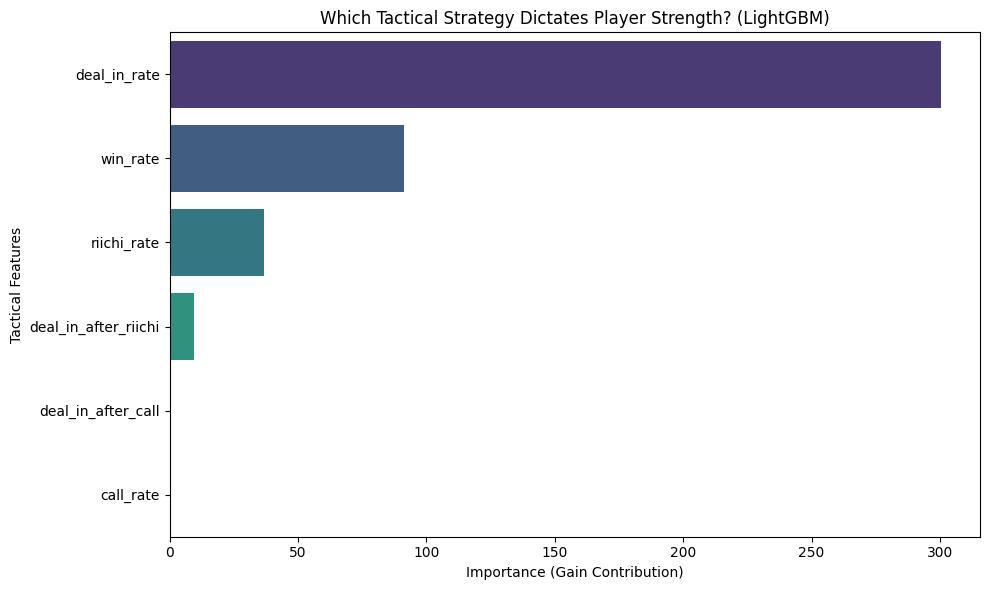

In [15]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 新しく生成された戦術CSVを合体
df_s = pd.read_csv("strong_tactical_stats.csv")
df_w = pd.read_csv("weak_tactical_stats.csv")
df = pd.concat([df_s, df_w], ignore_index=True)

# 順位や試合数を一切排除した、純粋な「対局中の戦略行為」だけを特徴量にする
X = df.drop(columns=['player_id', 'is_strong'])
y = df['is_strong']

# 訓練用とテスト用に分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'min_data_in_leaf': 2,
    'learning_rate': 0.05,
    'seed': 42,
    'verbose': -1
}

print("真・戦略特化型モデルの学習を開始します...")
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=100,
    callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
)

y_pred = np.where(model.predict(X_test) > 0.5, 1, 0)
print(f"\n純粋な戦略データのみでの予測正解率: {accuracy_score(y_test, y_pred) * 100:.1f}%")

# 特徴量重要度の可視化
importance = model.feature_importance(importance_type='gain')
feature_importance_df = pd.DataFrame({
    'Strategy_Tactics': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\n--- 【卒論の核】麻雀戦略の重要度ランキング ---")
print(feature_importance_df)

# グラフ描画
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Strategy_Tactics', data=feature_importance_df, palette='viridis', hue='Strategy_Tactics', legend=False)
plt.title('Which Tactical Strategy Dictates Player Strength? (LightGBM)', fontsize=12)
plt.xlabel('Importance (Gain Contribution)')
plt.ylabel('Tactical Features')
plt.tight_layout()
plt.show()